# Instructor Effectiveness Analysis — Data Science Internship Assignment

**Objective:** Explore the `instructor_effectiveness_dataset` (2,000 rows) to understand what drives instructor/course effectiveness, and build a predictive model that estimates a course's **completion rate** from engagement and performance signals.

**Structure of this notebook:**
1. Data Loading
2. Data Cleaning & Sanity Checks
3. Exploratory Data Analysis (univariate, bivariate, correlations)
4. Statistical Testing
5. Feature Engineering — a composite Instructor Effectiveness Score
6. Predictive Modeling (Regression)
7. Instructor-level Aggregation & Ranking
8. Conclusions & Recommendations


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)


## 1. Data Loading

**Before running this notebook:** download the dataset as a CSV and place it in the same folder as this notebook.

1. Open the Google Sheet
2. `File -> Download -> Comma Separated Values (.csv)`
3. Save it as `instructor_effectiveness_dataset_2000_rows.csv` next to this notebook (or update `DATA_PATH` below)


In [12]:
DATA_PATH = "/content/instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
display(df.head())

(2000, 12)


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [14]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
completion_rate,2000.0,0.602808,0.159667,0.300000,0.489260,0.603091,0.712797,0.980000
avg_score_improvement,2000.0,27.035844,5.716641,6.159240,23.124673,26.938629,30.885600,40.000000
avg_quiz_score,2000.0,77.956126,10.695618,40.386725,70.897590,78.020567,85.444286,100.000000
dropout_rate,2000.0,0.394883,0.162747,0.020000,0.280035,0.394820,0.511432,0.700000
avg_watch_time,2000.0,0.776515,0.145231,0.287440,0.675076,0.780330,0.894242,1.000000
assignment_submission_rate,2000.0,0.753188,0.148058,0.251111,0.652110,0.756380,0.856458,1.000000
forum_activity_rate,2000.0,0.250300,0.100640,0.000000,0.179845,0.249771,0.319204,0.641111
avg_feedback_score,2000.0,4.207134,0.419209,2.639915,3.918986,4.205989,4.503437,5.000000
feedback_response_rate,2000.0,0.736519,0.149412,0.259935,0.633293,0.737213,0.845876,1.000000


## 2. Data Cleaning & Sanity Checks

Checks performed:
- Missing values
- Duplicate rows
- Range checks on rate/proportion columns (should lie in [0, 1] where applicable)
- Data types for ID columns (`batch_id`, `instructor_id`, `course_id`) kept as categorical/string


In [15]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

rate_cols = ["completion_rate", "dropout_rate", "assignment_submission_rate",
             "forum_activity_rate", "feedback_response_rate"]
for c in rate_cols:
    if c in df.columns:
        print(f"{c}: min={df[c].min():.3f}, max={df[c].max():.3f}")


Missing values per column:
 batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

Duplicate rows: 0
completion_rate: min=0.300, max=0.980
dropout_rate: min=0.020, max=0.700
assignment_submission_rate: min=0.251, max=1.000
forum_activity_rate: min=0.000, max=0.641
feedback_response_rate: min=0.260, max=1.000


In [16]:
for col in ["batch_id", "instructor_id", "course_id"]:
    if col in df.columns:
        df[col] = df[col].astype(str)

print("Unique instructors:", df["instructor_id"].nunique())
print("Unique courses:", df["course_id"].nunique())
print("Unique batches:", df["batch_id"].nunique())


Unique instructors: 120
Unique courses: 25
Unique batches: 2000


## 3. Exploratory Data Analysis

### 3.1 Distributions of key numeric features

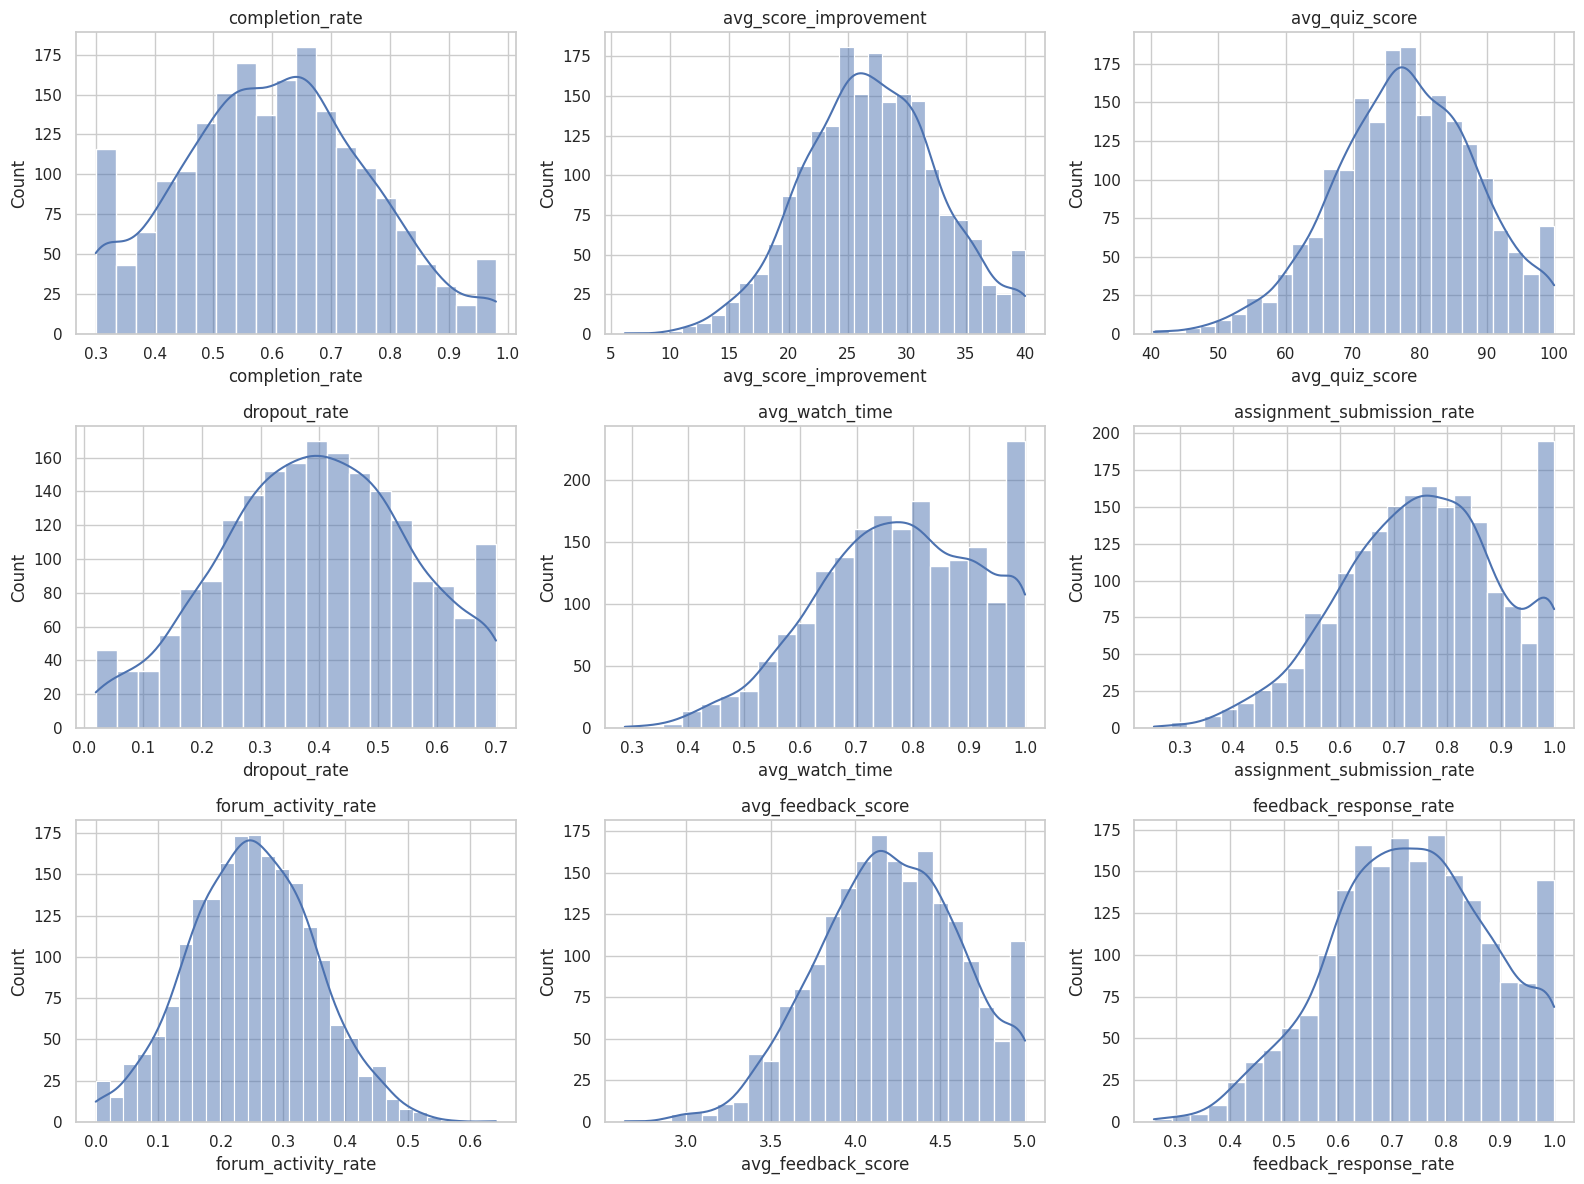

In [17]:
num_cols = ["completion_rate", "avg_score_improvement", "avg_quiz_score", "dropout_rate",
            "avg_watch_time", "assignment_submission_rate", "forum_activity_rate",
            "avg_feedback_score", "feedback_response_rate"]
num_cols = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()


### 3.2 Correlation heatmap

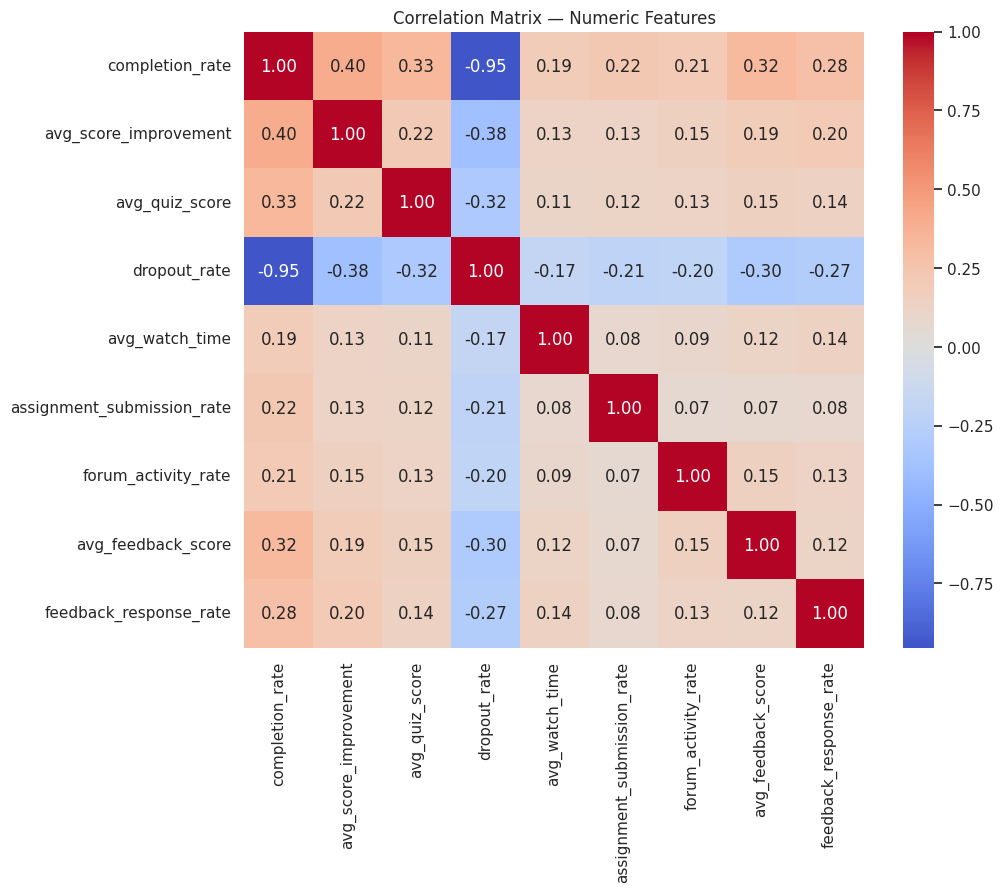

In [18]:
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numeric Features")
plt.show()


### 3.3 Relationship between engagement and completion

`completion_rate` is our primary outcome of interest. Let's see how it relates to `dropout_rate`, `assignment_submission_rate`, and `avg_watch_time`.

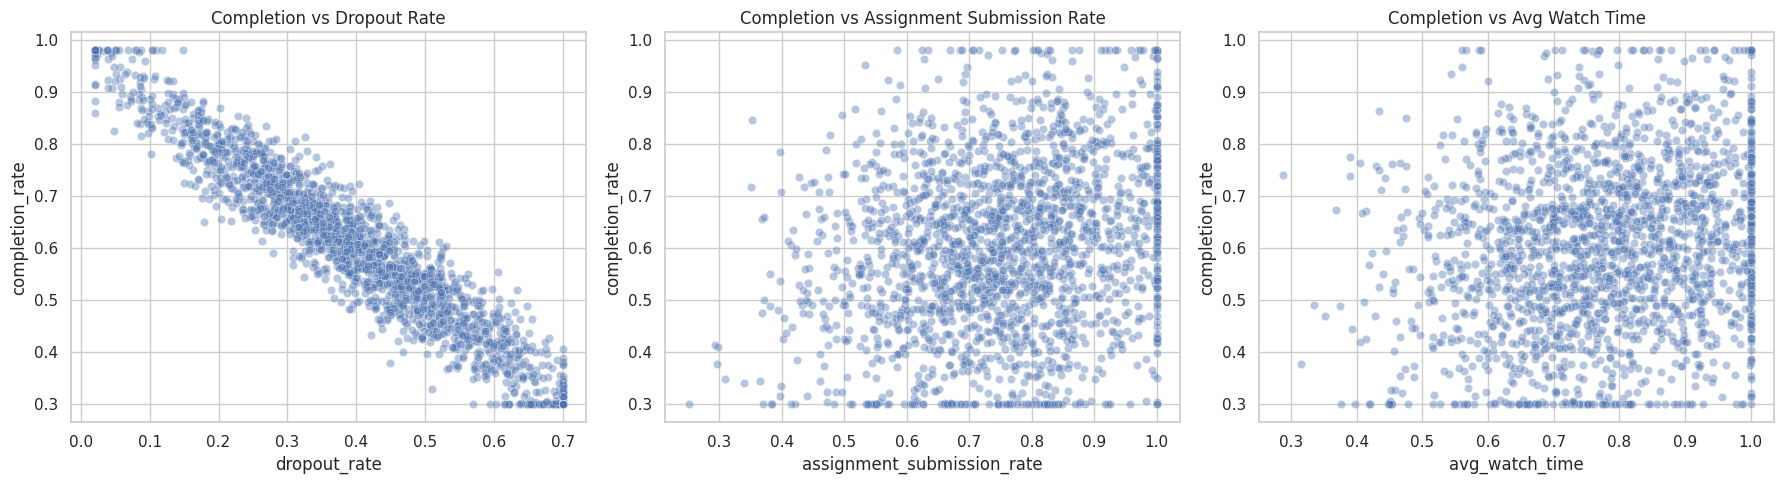

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=df, x="dropout_rate", y="completion_rate", ax=axes[0], alpha=0.4)
axes[0].set_title("Completion vs Dropout Rate")

sns.scatterplot(data=df, x="assignment_submission_rate", y="completion_rate", ax=axes[1], alpha=0.4)
axes[1].set_title("Completion vs Assignment Submission Rate")

sns.scatterplot(data=df, x="avg_watch_time", y="completion_rate", ax=axes[2], alpha=0.4)
axes[2].set_title("Completion vs Avg Watch Time")
plt.tight_layout()
plt.show()


### 3.4 Course-level comparison

Which courses have the highest average completion rates?

In [20]:
course_summary = (df.groupby("course_id")[["completion_rate", "avg_feedback_score", "dropout_rate"]]
                     .mean()
                     .sort_values("completion_rate", ascending=False))
course_summary.head(10)


,completion_rate,avg_feedback_score,dropout_rate
course_id,,,
C_20,0.639422,4.286632,0.369110
C_14,0.639152,4.193211,0.354628
C_05,0.630338,4.237671,0.366026
C_21,0.625749,4.192291,0.379254
C_06,0.622184,4.315455,0.376161
C_24,0.617382,4.274605,0.384503
C_25,0.616483,4.252313,0.384348
C_01,0.611400,4.218196,0.375943
C_11,0.607435,4.106599,0.387605


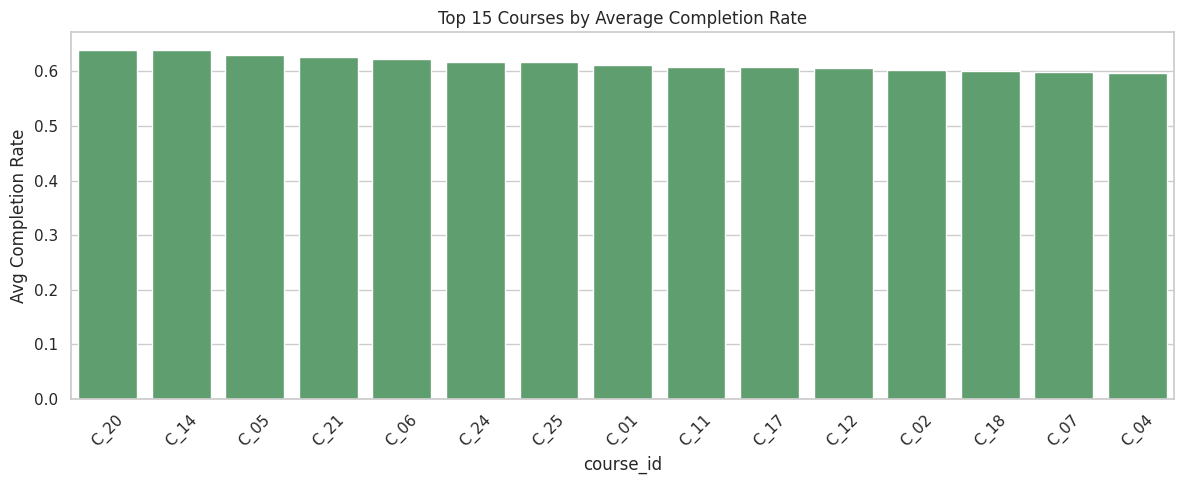

In [21]:
plt.figure(figsize=(12, 5))
top_courses = course_summary.head(15)
sns.barplot(x=top_courses.index, y=top_courses["completion_rate"], color="#55A868")
plt.xticks(rotation=45)
plt.title("Top 15 Courses by Average Completion Rate")
plt.ylabel("Avg Completion Rate")
plt.tight_layout()
plt.show()


## 4. Statistical Testing

**Hypothesis:** Instructors whose courses have above-median `forum_activity_rate` have a significantly different mean `completion_rate` than those below the median.

We use an independent-samples t-test (Welch's, unequal variance assumed).

In [22]:
median_forum = df["forum_activity_rate"].median()
high_engagement = df[df["forum_activity_rate"] >= median_forum]["completion_rate"]
low_engagement = df[df["forum_activity_rate"] < median_forum]["completion_rate"]

t_stat, p_value = stats.ttest_ind(high_engagement, low_engagement, equal_var=False)
print(f"High-engagement mean completion: {high_engagement.mean():.4f}")
print(f"Low-engagement mean completion:  {low_engagement.mean():.4f}")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_value:.4g}")

alpha = 0.05
if p_value < alpha:
    print("=> Statistically significant difference (reject H0).")
else:
    print("=> No statistically significant difference (fail to reject H0).")


High-engagement mean completion: 0.6250
Low-engagement mean completion:  0.5806
t-statistic = 6.285, p-value = 4.002e-10
=> Statistically significant difference (reject H0).


## 5. Feature Engineering — Instructor Effectiveness Score

We construct a simple composite score (0–100) combining outcome and engagement signals, min-max scaled and weighted. Weights are a reasonable business judgment call — they can be tuned with stakeholder input.

- `completion_rate` (35%)
- `avg_score_improvement` (25%)
- `avg_feedback_score` (20%)
- `assignment_submission_rate` (10%)
- `1 - dropout_rate` (10%)


In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(df[["completion_rate", "avg_score_improvement", "avg_feedback_score",
                              "assignment_submission_rate", "dropout_rate"]]),
    columns=["completion_rate", "avg_score_improvement", "avg_feedback_score",
             "assignment_submission_rate", "dropout_rate"],
    index=df.index
)

df["effectiveness_score"] = (
    0.35 * scaled["completion_rate"] +
    0.25 * scaled["avg_score_improvement"] +
    0.20 * scaled["avg_feedback_score"] +
    0.10 * scaled["assignment_submission_rate"] +
    0.10 * (1 - scaled["dropout_rate"])
) * 100

df[["instructor_id", "course_id", "effectiveness_score"]].sort_values(
    "effectiveness_score", ascending=False).head(10)


,instructor_id,course_id,effectiveness_score
1157,I_037,C_20,97.571191
1166,I_118,C_12,97.456105
1338,I_091,C_20,96.085916
685,I_010,C_20,95.914517
1549,I_118,C_11,95.154327
1407,I_018,C_20,94.843245
744,I_051,C_06,94.734464
1443,I_018,C_02,93.937504
393,I_037,C_11,93.501838
103,I_018,C_24,92.339741


## 6. Predictive Modeling — Regression

We train a model to predict `completion_rate` from the other engagement/performance features (excluding leakage from `dropout_rate`, which is near-definitionally related, and excluding our own engineered score).

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

feature_cols = ["avg_score_improvement", "avg_quiz_score", "avg_watch_time",
                 "assignment_submission_rate", "forum_activity_rate",
                 "avg_feedback_score", "feedback_response_rate"]
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols]
y = df["completion_rate"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds) ** 0.5,
        "R2": r2_score(y_test, preds)
    }

pd.DataFrame(results).T


,MAE,RMSE,R2
Linear Regression,0.111917,0.135414,0.334563
Random Forest,0.115324,0.140658,0.282024


### 6.1 Feature importance (Random Forest)

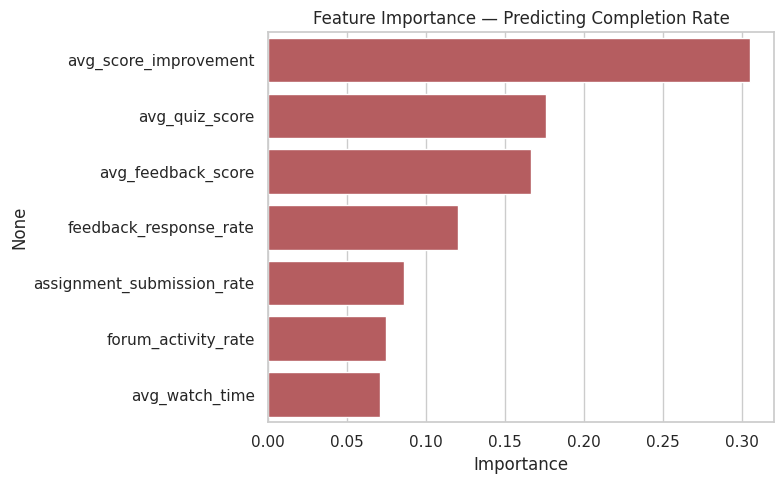

,0
avg_score_improvement,0.305149
avg_quiz_score,0.176020
avg_feedback_score,0.166816
feedback_response_rate,0.120160
assignment_submission_rate,0.086125
forum_activity_rate,0.075004
avg_watch_time,0.070726


In [25]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, color="#C44E52")
plt.title("Feature Importance — Predicting Completion Rate")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances


### 6.2 Predicted vs Actual

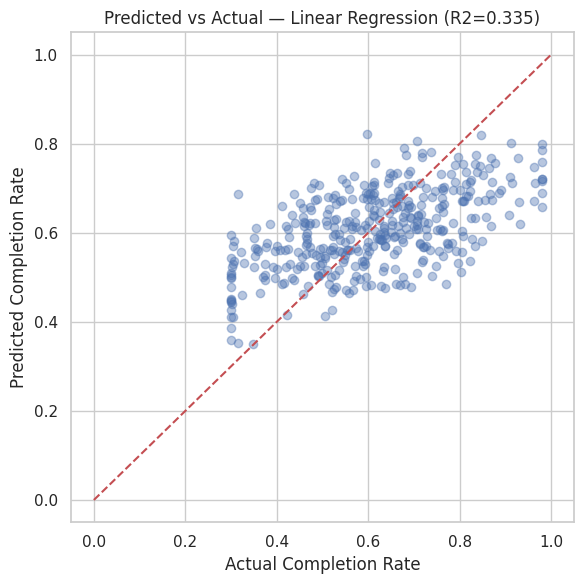

In [26]:
best_name = max(results, key=lambda k: results[k]["R2"])
best_model = models[best_name]
preds = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.4)
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("Actual Completion Rate")
plt.ylabel("Predicted Completion Rate")
plt.title(f"Predicted vs Actual — {best_name} (R2={results[best_name]['R2']:.3f})")
plt.tight_layout()
plt.show()


## 7. Instructor-Level Aggregation & Ranking

Roll the row-level (batch-course) data up to the instructor level to identify top and bottom performers.

In [27]:
instructor_summary = (df.groupby("instructor_id")
                         .agg(avg_completion_rate=("completion_rate", "mean"),
                              avg_effectiveness_score=("effectiveness_score", "mean"),
                              avg_feedback_score=("avg_feedback_score", "mean"),
                              n_batches=("batch_id", "nunique"))
                         .sort_values("avg_effectiveness_score", ascending=False))

print("Top 10 instructors:")
display(instructor_summary.head(10))

print("\nBottom 10 instructors (candidates for support/training):")
display(instructor_summary.tail(10))


Top 10 instructors:


,avg_completion_rate,avg_effectiveness_score,avg_feedback_score,n_batches
instructor_id,,,,
I_010,0.940783,87.507828,4.552640,13
I_037,0.923555,85.288541,4.532852,15
I_091,0.897119,84.104141,4.490270,8
I_018,0.867026,81.539999,4.635637,14
I_105,0.863880,81.186768,4.507488,16
I_118,0.820753,78.373405,4.641986,19
I_005,0.859747,78.085035,4.202516,19
I_025,0.822837,75.280935,4.374507,19
I_051,0.793270,74.430542,4.479606,26



Bottom 10 instructors (candidates for support/training):


,avg_completion_rate,avg_effectiveness_score,avg_feedback_score,n_batches
instructor_id,,,,
I_070,0.391366,36.596612,3.888164,15
I_038,0.395359,36.239403,3.960638,20
I_036,0.412399,35.573217,3.875844,21
I_061,0.406320,35.407376,3.963573,15
I_074,0.389739,35.282232,3.997632,17
I_067,0.400898,33.261737,3.791416,14
I_113,0.356493,31.631764,3.888738,26
I_050,0.335282,28.076048,3.736749,12
I_075,0.313393,27.062208,3.834521,19
